# Построение регрессионных моделей для уточнения срока беременности по показаниям УЗИ на ранних сроках беременности

ВКР по курсу: Многомерный анализ данных с использованием библиотек языка Python

Выполнила: Блинова Елена

План:

1. предварительный анализ датасета с результатами ультразвукового исследования женщин  первого триместра беременности( более 2000 женщин, 8 измерений для каждого плода) - пропущенные значения, выбросы, описательная статистика, визуализация, ...
2.  многомерный корреляционный анализ для выявления наиболее значимых показателей и анализа мультиколлинеарности
3. различные регрессионные модели для уточнения срока беременности по основным показателям (линейная, полиномиальные, Лассо), проведён анализ качества и аддекватности моделей.
4. Выбор оптимальной модели

## Предварительный анализ датасета
- подготовка данных
- пропущенные значения
- выборсы
- описательная статистика
- визуализация

In [1]:
# импорт необходимых библиотек
import pandas as pd
import numpy as np
import seaborn as sb

import matplotlib
from matplotlib import pyplot as plt

from scipy import stats
from scipy.stats import pearsonr

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson

import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import Lasso               #  регрессия Лассо
from sklearn.linear_model import LinearRegression    #  линейная регрессия
from sklearn.preprocessing import PolynomialFeatures #  полиномиальная регрессия
from sklearn.model_selection import train_test_split # для разбиения выборки на тестовую и обучающую

### Подготовка данных:
- загрузка датасета
- первичный осмотр данных (просмотр первых и последних строк, проверка типов)

In [2]:
#Монтирование Google Диска
from google.colab import drive
drive.mount('/content/drive',force_remount=True)
df=pd.read_excel('/content/drive/My Drive/Colab Notebooks/ДАТАСЕТЫ/УЗИ.xlsx')
df

Mounted at /content/drive


,DAR,DATAV,GR2,BPR,OG,DBK,LZR,OGOL,PLK,BBK,LUK
0,1979-07-29,2000-03-31,20,45,47,30,63,0,30,27,25
1,1974-12-02,2000-09-01,20,47,47,31,61,0,30,28,26
2,1974-04-14,2001-06-06,20,49,48,33,65,0,32,28,27
3,1974-01-25,2001-09-20,20,42,47,31,56,0,29,24,24
4,1965-11-25,2001-10-24,20,49,48,31,64,0,29,28,26
...,...,...,...,...,...,...,...,...,...,...,...
2701,1983-04-06,2005-02-05,28,72,75,54,96,84,49,45,40
2702,1984-08-31,2005-03-15,28,72,73,55,90,81,46,47,39
2703,1975-07-29,2005-06-16,28,67,73,53,93,80,48,46,38
2704,1980-01-23,2005-06-21,28,74,79,51,91,83,48,46,41


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2706 entries, 0 to 2705
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0    DAR         2706 non-null   object
 1    DATAV       2706 non-null   object
 2    GR2         2706 non-null   int64 
 3    BPR         2706 non-null   int64 
 4    OG          2706 non-null   int64 
 5    DBK         2706 non-null   int64 
 6    LZR         2706 non-null   int64 
 7    OGOL        2706 non-null   int64 
 8    PLK         2706 non-null   int64 
 9    BBK         2706 non-null   int64 
 10   LUK         2706 non-null   int64 
dtypes: int64(9), object(2)
memory usage: 232.7+ KB


In [4]:
# Удаление начальных и конечных пробелов из имен столбцов
df.columns = df.columns.str.strip()
df.columns

Index(['DAR', 'DATAV', 'GR2', 'BPR', 'OG', 'DBK', 'LZR', 'OGOL', 'PLK', 'BBK',
       'LUK'],
      dtype='object')

Датасет состоит из 2706 проведенных наблюдений по 9 переменным и 2-м значениям даты.

Пропущенных значений не имеется, применение обработки пропущенных значений не требуется.

Показатель GR2 отвечает за срок беременности

### Обработка выбросов
- определение выбросов с импользованием метода  Z-score
- решение о стратегии обработки выбросов (замена, удаление или корректировка)

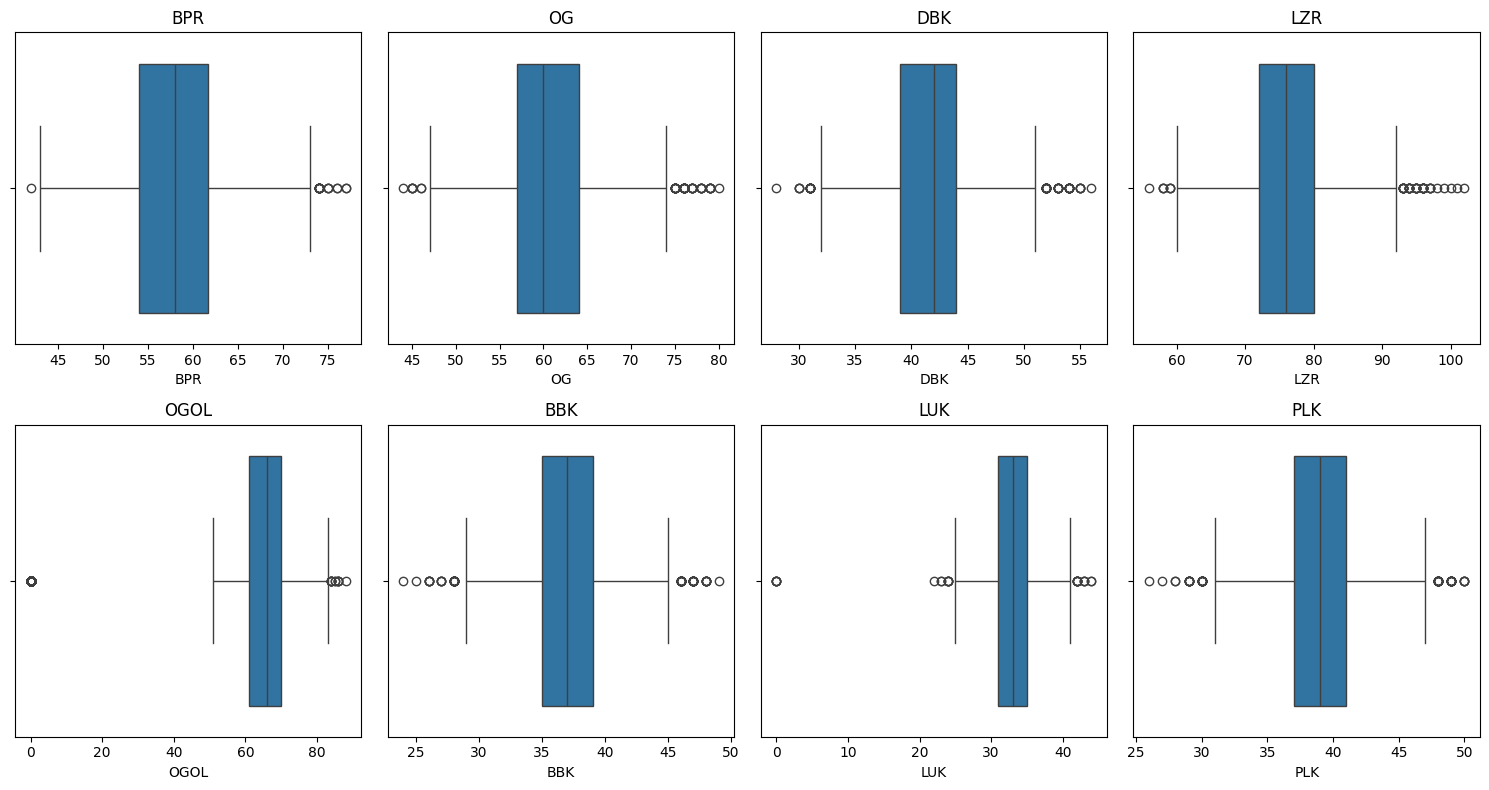

In [5]:
#визуализация выбросов
def boxplot(df2):
  plt.figure(figsize=(15, 8))

  plt.subplot(241)
  sb.boxplot(x=df2['BPR'])
  plt.title("BPR")

  plt.subplot(242)
  sb.boxplot(x=df2['OG'])
  plt.title("OG")

  plt.subplot(243)
  sb.boxplot(x=df2['DBK'])
  plt.title("DBK")

  plt.subplot(244)
  sb.boxplot(x=df2['LZR'])
  plt.title("LZR")

  plt.subplot(245)
  sb.boxplot(x=df2['OGOL'])
  plt.title("OGOL")

  plt.subplot(246)
  sb.boxplot(x=df2['BBK'])
  plt.title("BBK")

  plt.subplot(247)
  sb.boxplot(x=df2['LUK'])
  plt.title("LUK")

  plt.subplot(248)
  sb.boxplot(x=df2['PLK'])
  plt.title("PLK")

  plt.tight_layout()
  plt.show()

boxplot(df)

На приведенном рисунке видно, что на всех графиках имеются выбросы.

Z-оценка — это статистическая мера, которая показывает, насколько значение отклоняется от среднего значения выборки в единицах стандартного отклонения.

In [6]:
# Z-score для всех столбцов в df
z_scores = np.abs(stats.zscore(df[["GR2", "BPR", "OG", "DBK", "LZR", "OGOL", "PLK", "BBK", "LUK"]]))
# Порог для определения выбросов. Обычно используется значение 3.
threshold = 3.5
# Поиск выбросов
outliers = np.where(z_scores > threshold)
outliers_count = len(outliers[0])
print(f"Количество выбросов: {outliers_count}")
outliers

Количество выбросов: 13


(array([   3,   12,   44, 1336, 1366, 1370, 2026, 2416, 2670, 2670, 2671,
        2674, 2678]),
 array([7, 6, 8, 8, 8, 8, 8, 4, 1, 4, 4, 3, 1]))

### Описательная статистика
- расчет основных статистических показателей
- анализ распределения данных

Выбраны следующие показатели.
1. Среднее (Mean). Это среднее арифметическое всех значений в столбце. Оно вычисляется как сумма всех значений, деленная на количество значений.
2. Медиана (Median). Это среднее значение в отсортированном наборе данных. Если количество значений нечетное, медиана - это среднее значение; если количество значений четное, медиана - это среднее двух средних значений.
3. Мода (Mode). Это наиболее часто встречающееся значение в наборе данных.
4. Стандартное отклонение (Std. Dev.). Это мера разброса значений относительно среднего значения. Большое стандартное отклонение указывает на большой разброс данных.
5. Дисперсия (Variance). Это квадрат стандартного отклонения. Она измеряет квадратичное отклонение значений от среднего.
6. Ковариация (Covariance).Это мера того, насколько две переменные изменяются вместе. Если значения двух переменных обычно увеличиваются или уменьшаются вместе, то ковариация положительна. Если одна переменная обычно увеличивается, когда другая уменьшается, то ковариация отрицательна.

In [7]:
# Использование метода describe() для получения сводной статистики DataFrame
df.describe()

,GR2,BPR,OG,DBK,LZR,OGOL,PLK,BBK,LUK
count,2706.000000,2706.000000,2706.000000,2706.000000,2706.000000,2706.000000,2706.000000,2706.000000,2706.000000
mean,23.677384,58.002956,60.570953,41.739468,76.298965,57.543607,39.024390,37.019956,32.817443
std,1.518263,5.427321,5.709766,4.013808,6.766098,24.175539,3.489111,3.632820,3.268050
min,20.000000,42.000000,44.000000,28.000000,56.000000,0.000000,26.000000,24.000000,0.000000
25%,23.000000,54.000000,57.000000,39.000000,72.000000,61.000000,37.000000,35.000000,31.000000
50%,24.000000,58.000000,60.000000,42.000000,76.000000,66.000000,39.000000,37.000000,33.000000
75%,25.000000,61.750000,64.000000,44.000000,80.000000,70.000000,41.000000,39.000000,35.000000
max,28.000000,77.000000,80.000000,56.000000,102.000000,88.000000,50.000000,49.000000,44.000000


In [8]:
df_without_date = df[["GR2", "BPR", "OG", "DBK", "LZR", "OGOL", "PLK", "BBK", "LUK"]]

# Вычисление основных статистических показателей
mean = df_without_date.mean()
median = df_without_date.median()
mode = df_without_date.mode()
std_dev = df_without_date.std()
variance = df_without_date.var()
covariance = df_without_date.cov()

# Вывод результатов
statistics_df = pd.DataFrame({
    "Mean": mean,
    "Median": median,
    "Std. Dev.": std_dev,
    "Variance": variance
})
print("\nСтатистика:\n", statistics_df)
print("\nМода:\n", mode)
print("\nКовариация:\n", df_without_date.cov())

current_df = df


Статистика:
            Mean  Median  Std. Dev.    Variance
GR2   23.677384    24.0   1.518263    2.305122
BPR   58.002956    58.0   5.427321   29.455814
OG    60.570953    60.0   5.709766   32.601433
DBK   41.739468    42.0   4.013808   16.110656
LZR   76.298965    76.0   6.766098   45.780088
OGOL  57.543607    66.0  24.175539  584.456693
PLK   39.024390    39.0   3.489111   12.173897
BBK   37.019956    37.0   3.632820   13.197384
LUK   32.817443    33.0   3.268050   10.680154

Мода:
    GR2  BPR  OG  DBK  LZR  OGOL  PLK  BBK  LUK
0   23   57  58   42   74     0   39   37   32

Ковариация:
            GR2        BPR         OG        DBK        LZR        OGOL  \
GR2   2.305122   7.274522   7.803121   5.633107   9.198150    4.354369   
BPR   7.274522  29.455814  26.633801  18.334227  31.417230   22.343309   
OG    7.803121  26.633801  32.601433  19.865627  33.719445   17.404483   
DBK   5.633107  18.334227  19.865627  16.110656  23.615812   11.230404   
LZR   9.198150  31.417230  33.

### Визуализация данных
- построение графиков для визуального анализа данных
- интерпретация графиков и выводы

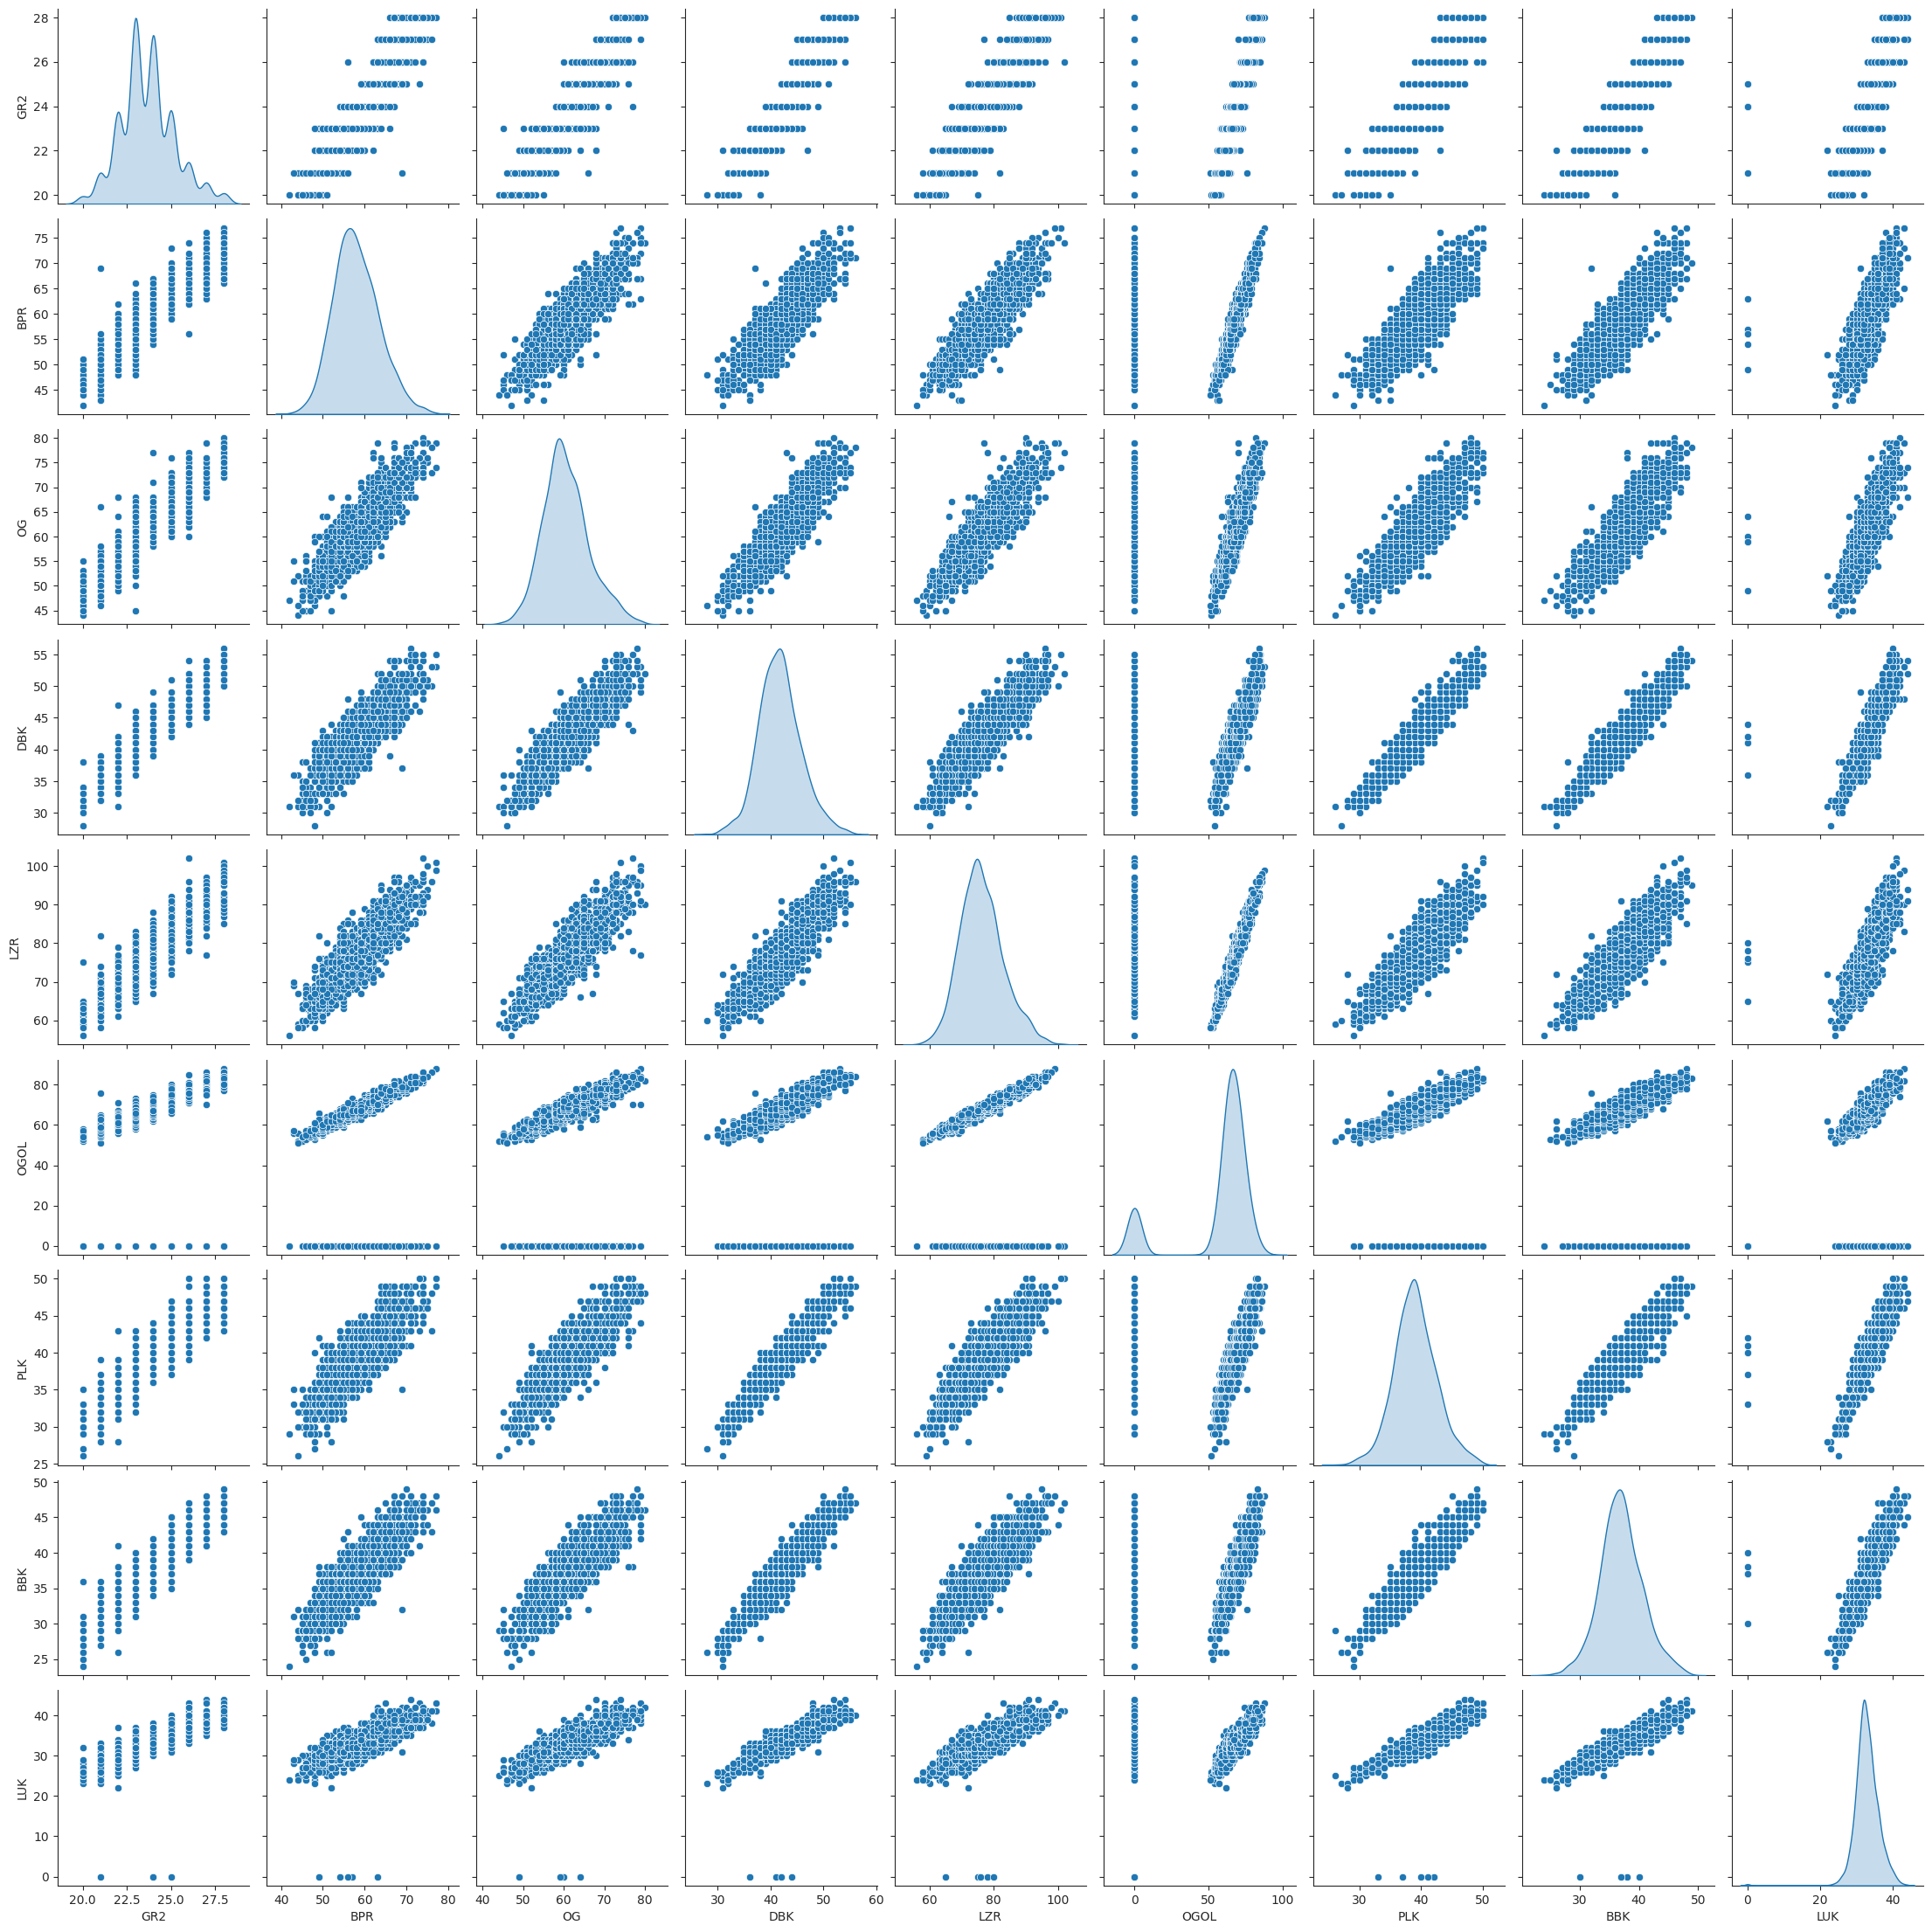

In [9]:
%matplotlib inline
sb.set_style("ticks")
sb.pairplot(current_df,diag_kind="kde")
plt.show()

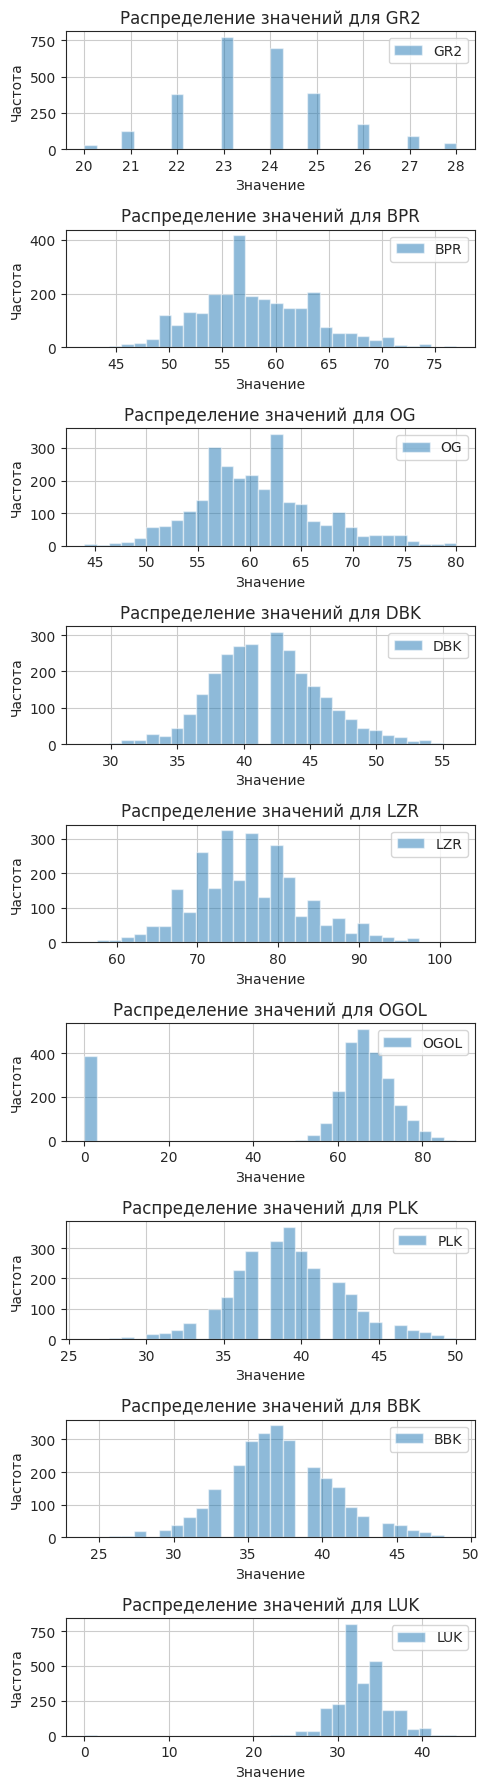

In [10]:
columns = df_without_date.columns
fig, axs = plt.subplots(len(columns), figsize=(5, 2*len(columns)))

# гистограмма для каждого столбца
for i, column in enumerate(columns):
    axs[i].hist(df_without_date[column], bins=30, alpha=0.5, label=column)
    axs[i].legend(loc='upper right')
    axs[i].set_title(f'Распределение значений для {column}')
    axs[i].set_xlabel('Значение')
    axs[i].set_ylabel('Частота')
    axs[i].grid(True)

plt.tight_layout()
plt.show()

На основе предоставленных гистограмм, можно сделать следующие выводы:
*   GR2: Распределение похоже на нормальное.
*   BPR: Распределение похоже на нормальное
*   OG: Распределение похоже на нормальное
*   DBK: Распределение похоже на нормальное
*   LZR: Распределение похоже на мультимодальное (имеется несколько пиков)
*   OGOL: Распределение бимодальное (имеется два пика)
*   PLK: Распределение похоже на нормальное.
*   BBK: Распределение похоже на нормальное.
*   LUK: Распределение похоже на нормальное.








## Многомерный корреляционный анализ для выявления наиболее значимых показателей и анализа мультиколлинеарности
*   многомерный корреляционный анализ
*   анализ мультиколлениарности
- подготовка даннных для дальнейшего анализа



### Многомерный корреляционный анализ:
- вычисление корреляционной матрицы для всех переменных
- визуализация корреляционной матрицы для определения взаимосвязей между переменными

In [11]:
corr_matrix = current_df[["GR2", "BPR", "OG", "DBK", "LZR", "OGOL", "PLK", "BBK", "LUK"]].corr()
corr_matrix

,GR2,BPR,OG,DBK,LZR,OGOL,PLK,BBK,LUK
GR2,1.000000,0.882820,0.900125,0.924367,0.895396,0.118632,0.900544,0.906887,0.791311
BPR,0.882820,1.000000,0.859467,0.841629,0.855547,0.170289,0.814567,0.825132,0.731450
OG,0.900125,0.859467,1.000000,0.866817,0.872818,0.126086,0.852647,0.847912,0.761154
DBK,0.924367,0.841629,0.866817,1.000000,0.869577,0.115734,0.932150,0.936269,0.816188
LZR,0.895396,0.855547,0.872818,0.869577,1.000000,0.080133,0.858743,0.852937,0.757725
OGOL,0.118632,0.170289,0.126086,0.115734,0.080133,1.000000,0.131354,0.143932,0.124557
PLK,0.900544,0.814567,0.852647,0.932150,0.858743,0.131354,1.000000,0.929738,0.819059
BBK,0.906887,0.825132,0.847912,0.936269,0.852937,0.143932,0.929738,1.000000,0.810597
LUK,0.791311,0.731450,0.761154,0.816188,0.757725,0.124557,0.819059,0.810597,1.000000


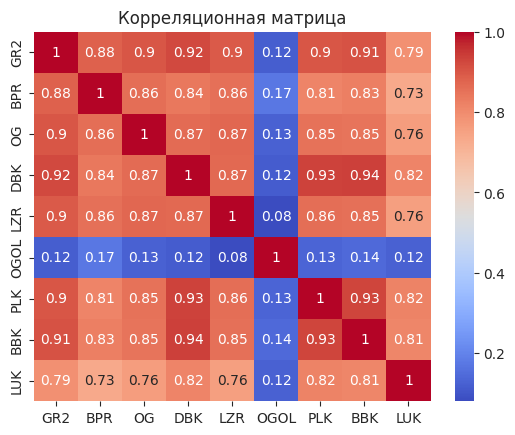

In [12]:
sb.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title('Корреляционная матрица')
plt.show()

In [13]:
print("Классификация коэффициентов корреляции по значимости по p-значению 0.01, 0.05, 0.1")
p_values = pd.DataFrame(index=df_without_date.columns, columns=df_without_date.columns)

# Calculate the p-values
for i in df_without_date.columns:
    for j in df_without_date.columns:
        p_values.loc[i, j] = round(pearsonr(df_without_date[i], df_without_date[j])[1], 3)

# Classify the significance of the correlations
significance_matrix = p_values.applymap(lambda x: ' Высокая' if x <= 0.01 else ('Значимо' if x <= 0.05 else 'Не значимо'))

# Print the significance matrix
print(significance_matrix)

Классификация коэффициентов корреляции по значимости по p-значению 0.01, 0.05, 0.1
           GR2       BPR        OG       DBK       LZR      OGOL       PLK  \
GR2    Высокая   Высокая   Высокая   Высокая   Высокая   Высокая   Высокая   
BPR    Высокая   Высокая   Высокая   Высокая   Высокая   Высокая   Высокая   
OG     Высокая   Высокая   Высокая   Высокая   Высокая   Высокая   Высокая   
DBK    Высокая   Высокая   Высокая   Высокая   Высокая   Высокая   Высокая   
LZR    Высокая   Высокая   Высокая   Высокая   Высокая   Высокая   Высокая   
OGOL   Высокая   Высокая   Высокая   Высокая   Высокая   Высокая   Высокая   
PLK    Высокая   Высокая   Высокая   Высокая   Высокая   Высокая   Высокая   
BBK    Высокая   Высокая   Высокая   Высокая   Высокая   Высокая   Высокая   
LUK    Высокая   Высокая   Высокая   Высокая   Высокая   Высокая   Высокая   

           BBK       LUK  
GR2    Высокая   Высокая  
BPR    Высокая   Высокая  
OG     Высокая   Высокая  
DBK    Высокая   Высокая  
L

In [14]:
print("Классификация коэффициентов корреляции по силе")

strength_matrix = corr_matrix.applymap(lambda x: 'Сильная' if x > 0.70 else ('Средняя' if 0.50 < x <= 0.70 else ('Умеренная' if 0.30 < x <= 0.50 else ('Слабая' if 0.20 < x <= 0.30 else 'Очень слабая'))))

# Print the strength matrix
print(strength_matrix)

Классификация коэффициентов корреляции по силе
               GR2           BPR            OG           DBK           LZR  \
GR2        Сильная       Сильная       Сильная       Сильная       Сильная   
BPR        Сильная       Сильная       Сильная       Сильная       Сильная   
OG         Сильная       Сильная       Сильная       Сильная       Сильная   
DBK        Сильная       Сильная       Сильная       Сильная       Сильная   
LZR        Сильная       Сильная       Сильная       Сильная       Сильная   
OGOL  Очень слабая  Очень слабая  Очень слабая  Очень слабая  Очень слабая   
PLK        Сильная       Сильная       Сильная       Сильная       Сильная   
BBK        Сильная       Сильная       Сильная       Сильная       Сильная   
LUK        Сильная       Сильная       Сильная       Сильная       Сильная   

              OGOL           PLK           BBK           LUK  
GR2   Очень слабая       Сильная       Сильная       Сильная  
BPR   Очень слабая       Сильная       Сильная

### Анализ мультиколлениарности:
- вычисление численных показателей мультиколлениарности
- значимые и незначимые коээфициенты
- Решение о стратегии обработки мультиколлинеарности (удаление переменных с высоким VIF или др.)

VIF определяет насколько степень увеличения дисперсии оценки коэффициента регрессии увеличивается из-за мультиколлинеарности, по сравнению с ситуацией, когда переменные не коррелируют.

In [15]:
numeric_cols = current_df.select_dtypes(include=[np.number])

vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(numeric_cols.values, i) for i in range(numeric_cols.shape[1])]
vif["Показатель"] = numeric_cols.columns

print(vif)

    VIF Factor Показатель
0   999.719711        GR2
1   615.733078        BPR
2   707.906231         OG
3  1316.952589        DBK
4   825.984889        LZR
5     7.036552       OGOL
6  1308.329842        PLK
7  1093.271263        BBK
8   340.095959        LUK


Переменные GR2, BPR, OG, DBK, LZR, PLK, BBK, LUK имеют очень высокие значения VIF, значительно превышающие 5, что считается порогом для высокой мультиколлинеарности. Это может указывать на сильную мультиколлинеарность между этими переменными.

Переменная OGOLимеет VIF, равный 7.28, что указывает на отсутствие сильной мультиколлинеарности.

### Выбор наиболее значимых показателей
- Определение наиболее значимых показателей на основе результатов корреляционного анализа и анализа мультиколлинеарности
- Проверка значимости выбранных показателей с использованием соответствующих статистических тестов ( t-тест, F-тест, коээфициент Спирмана, коэффициент Пирсона, хи-квадрат)

Незначимыми переменными выбраны OGOL','LUK'

In [16]:
# столбцы в модель
cols_to_include = ['BPR', 'OG', 'DBK', 'LZR', 'PLK', 'BBK']

X = current_df[cols_to_include]
y = current_df['GR2']  # целевого столбца

X = sm.add_constant(X)
model = sm.OLS(y, X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                    GR2   R-squared:                       0.915
Model:                            OLS   Adj. R-squared:                  0.915
Method:                 Least Squares   F-statistic:                     4872.
Date:                Mon, 17 Jun 2024   Prob (F-statistic):               0.00
Time:                        16:07:52   Log-Likelihood:                -1626.1
No. Observations:                2706   AIC:                             3266.
Df Residuals:                    2699   BIC:                             3308.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.3026      0.101     71.950      0.0

In [17]:
# Perform a t-test
print("\\nT-test:")
for col in X.columns:
    t_test_results = stats.ttest_ind(X[col], y)
    print(f"For {col}: t-statistic = {t_test_results[0]}, p-value = {t_test_results[1]}")

# Perform an F-test
print("\\n F-test:")
f_test_results = stats.f_oneway(current_df['GR2'], current_df['BPR'], current_df['OG'], current_df['DBK'], current_df['LZR'], current_df['OGOL'], current_df['PLK'], current_df['BBK'], current_df['LUK'])
print(f"F-statistic = {f_test_results[0]}, p-value = {f_test_results[1]}")

# Calculate Spearman's rank correlation coefficient
print("\\n Spearman's rank correlation coefficient results:")
for col in X.columns:
    spearman_results = stats.spearmanr(X[col], y)
    print(f"For {col}: Spearman's rank correlation coefficient = {spearman_results[0]}, p-value = {spearman_results[1]}")

# Calculate Pearson's correlation coefficient
print("\\n Pearson's correlation coefficient results:")
for col in X.columns:
    pearson_results = stats.pearsonr(X[col], y)
    print(f"For {col}: Pearson's correlation coefficient = {pearson_results[0]}, p-value = {pearson_results[1]}")

\nT-test:
For const: t-statistic = -776.98002602432, p-value = 0.0
For BPR: t-statistic = 316.83637960702634, p-value = 0.0
For OG: t-statistic = 324.8336990562272, p-value = 0.0
For DBK: t-statistic = 218.9458507172096, p-value = 0.0
For LZR: t-statistic = 394.7499061694083, p-value = 0.0
For PLK: t-statistic = 209.8060512480727, p-value = 0.0
For BBK: t-statistic = 176.27978068785032, p-value = 0.0
\n F-test:
F-statistic = 9006.400604188353, p-value = 0.0
\n Spearman's rank correlation coefficient results:
For const: Spearman's rank correlation coefficient = nan, p-value = nan
For BPR: Spearman's rank correlation coefficient = 0.8691956247867398, p-value = 0.0
For OG: Spearman's rank correlation coefficient = 0.8892552915275489, p-value = 0.0
For DBK: Spearman's rank correlation coefficient = 0.9128348481559407, p-value = 0.0
For LZR: Spearman's rank correlation coefficient = 0.8816230045752226, p-value = 0.0
For PLK: Spearman's rank correlation coefficient = 0.8886740208256513, p-va

/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:523: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.10/dist-packages/scipy/stats/_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
/usr/local/lib/python3.10/dist-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


In [19]:
p_values = results.pvalues
significant_coeffs = p_values[p_values < 0.05]

print('Significant coefficients:', significant_coeffs)

Significant coefficients: const    0.000000e+00
BPR      6.019799e-47
OG       6.562762e-45
DBK      5.620382e-43
LZR      4.712174e-27
PLK      7.308115e-05
BBK      3.258757e-15
dtype: float64


Незначимые переменные: OGOL, Luk

### Подготовка данных для дальнейшего анализа
- Создание нового датасета только с наиболее значимыми показателями для дальнейшего построения регрессионных моделей

In [21]:
result_df = current_df.copy()
Y = result_df["GR2"]    #  результативная переменная
X = result_df.drop(["GR2",'DAR','DATAV',"OGOL", "LUK" ],axis=1)   # факторы (исключаем столбцы)
print(result_df)
print(X.columns)

              DAR        DATAV  GR2  BPR  OG  DBK  LZR  OGOL  PLK  BBK  LUK
0      1979-07-29   2000-03-31   20   45  47   30   63     0   30   27   25
1      1974-12-02   2000-09-01   20   47  47   31   61     0   30   28   26
2      1974-04-14   2001-06-06   20   49  48   33   65     0   32   28   27
3      1974-01-25   2001-09-20   20   42  47   31   56     0   29   24   24
4      1965-11-25   2001-10-24   20   49  48   31   64     0   29   28   26
...           ...          ...  ...  ...  ..  ...  ...   ...  ...  ...  ...
2701   1983-04-06   2005-02-05   28   72  75   54   96    84   49   45   40
2702   1984-08-31   2005-03-15   28   72  73   55   90    81   46   47   39
2703   1975-07-29   2005-06-16   28   67  73   53   93    80   48   46   38
2704   1980-01-23   2005-06-21   28   74  79   51   91    83   48   46   41
2705   1985-05-31   2005-12-01   28   67  78   54   93    80   47   46   39

[2706 rows x 11 columns]
Index(['BPR', 'OG', 'DBK', 'LZR', 'PLK', 'BBK'], dtype='object

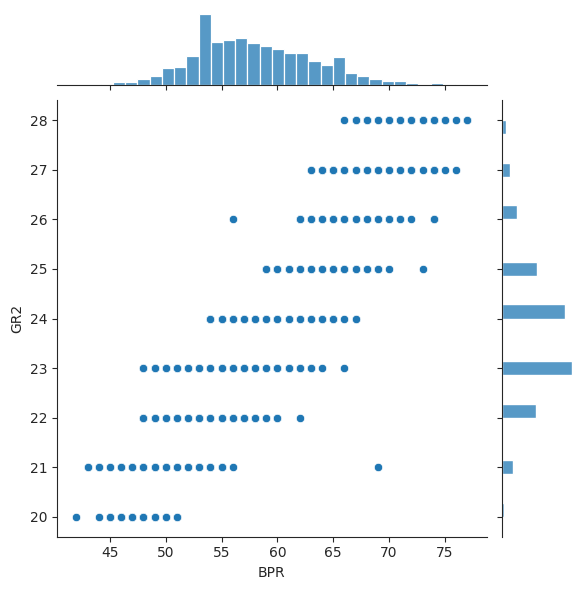

In [22]:
sb.jointplot(x='BPR', y="GR2", data=current_df)
plt.show()

На графике приведена диаграмма рассеяния, показывающая связь между двумя показателями.

## Регрессионные модели модели для уточнения срока беременности по основным показателям
- линейная
- полиномиальные
- Лассо
- анализ качества и аддекватности моделей

### Построение линейной регрессионной модели
Index(['BPR', 'OG', 'DBK', 'LZR', 'PLK', 'BBK', 'LUK'], dtype='object')

In [23]:
# использование модуля statsmodels для линейной регрессии - парная регрессия
y = result_df["GR2"]
x = result_df['BPR']
x = sm.add_constant(x) # включение свободного члена в модель
model_BPR = sm.OLS(y, x).fit()  #  подгонка модели
print(model_BPR.summary())# таблица статистик
print(model_BPR.params)

                            OLS Regression Results                            
Dep. Variable:                    GR2   R-squared:                       0.779
Model:                            OLS   Adj. R-squared:                  0.779
Method:                 Least Squares   F-statistic:                     9552.
Date:                Mon, 17 Jun 2024   Prob (F-statistic):               0.00
Time:                        16:09:26   Log-Likelihood:                -2924.3
No. Observations:                2706   AIC:                             5853.
Df Residuals:                    2704   BIC:                             5864.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.3527      0.147     63.534      0.0

####Остальные парные регрессии

In [24]:
# использование модуля statsmodels для линейной регрессии - парная регрессия
y = result_df["GR2"]
x = result_df['OG']
x = sm.add_constant(x) # включение свободного члена в модель
model_OG = sm.OLS(y, x).fit()  #  подгонка модели
print(model_OG.summary())# таблица статистик
print(model_OG.params)

                            OLS Regression Results                            
Dep. Variable:                    GR2   R-squared:                       0.810
Model:                            OLS   Adj. R-squared:                  0.810
Method:                 Least Squares   F-statistic:                 1.154e+04
Date:                Mon, 17 Jun 2024   Prob (F-statistic):               0.00
Time:                        16:09:30   Log-Likelihood:                -2720.5
No. Observations:                2706   AIC:                             5445.
Df Residuals:                    2704   BIC:                             5457.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.1798      0.136     67.734      0.0

In [25]:
# использование модуля statsmodels для линейной регрессии - парная регрессия
y = result_df["GR2"]
x = result_df['DBK']
x = sm.add_constant(x) # включение свободного члена в модель
model_DBK = sm.OLS(y, x).fit()  #  подгонка модели
print(model_DBK.summary())# таблица статистик
print(model_DBK.params)# таблица статистик

                            OLS Regression Results                            
Dep. Variable:                    GR2   R-squared:                       0.854
Model:                            OLS   Adj. R-squared:                  0.854
Method:                 Least Squares   F-statistic:                 1.587e+04
Date:                Mon, 17 Jun 2024   Prob (F-statistic):               0.00
Time:                        16:09:32   Log-Likelihood:                -2361.5
No. Observations:                2706   AIC:                             4727.
Df Residuals:                    2704   BIC:                             4739.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.0831      0.116     78.056      0.0

In [26]:
# использование модуля statsmodels для линейной регрессии - парная регрессия
y = result_df["GR2"]
x = result_df['LZR']
x = sm.add_constant(x) # включение свободного члена в модель
model_LZR = sm.OLS(y, x).fit()  #  подгонка модели
print(model_LZR.summary())# таблица статистик
print(model_LZR.params)

                            OLS Regression Results                            
Dep. Variable:                    GR2   R-squared:                       0.802
Model:                            OLS   Adj. R-squared:                  0.802
Method:                 Least Squares   F-statistic:                 1.093e+04
Date:                Mon, 17 Jun 2024   Prob (F-statistic):               0.00
Time:                        16:09:35   Log-Likelihood:                -2779.7
No. Observations:                2706   AIC:                             5563.
Df Residuals:                    2704   BIC:                             5575.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.3474      0.147     56.715      0.0

In [27]:
# использование модуля statsmodels для линейной регрессии - парная регрессия
y = result_df["GR2"]
x = result_df['PLK']
x = sm.add_constant(x) # включение свободного члена в модель
model_PLK = sm.OLS(y, x).fit()  #  подгонка модели
print(model_PLK.summary())# таблица статистик
print(model_PLK.params)#

                            OLS Regression Results                            
Dep. Variable:                    GR2   R-squared:                       0.811
Model:                            OLS   Adj. R-squared:                  0.811
Method:                 Least Squares   F-statistic:                 1.160e+04
Date:                Mon, 17 Jun 2024   Prob (F-statistic):               0.00
Time:                        16:09:38   Log-Likelihood:                -2715.1
No. Observations:                2706   AIC:                             5434.
Df Residuals:                    2704   BIC:                             5446.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.3851      0.143     58.825      0.0

In [28]:
# использование модуля statsmodels для линейной регрессии - парная регрессия
y = result_df["GR2"]
x = result_df['BBK']
x = sm.add_constant(x) # включение свободного члена в модель
model_BBK = sm.OLS(y, x).fit()  #  подгонка модели
print(model_BBK.summary())# таблица статистик
print(model_BBK.params)

                            OLS Regression Results                            
Dep. Variable:                    GR2   R-squared:                       0.822
Model:                            OLS   Adj. R-squared:                  0.822
Method:                 Least Squares   F-statistic:                 1.252e+04
Date:                Mon, 17 Jun 2024   Prob (F-statistic):               0.00
Time:                        16:09:41   Log-Likelihood:                -2630.5
No. Observations:                2706   AIC:                             5265.
Df Residuals:                    2704   BIC:                             5277.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.6463      0.126     76.573      0.0

#### проверка условий Гаусса-Маркова для остатков

Статистика теста Жарка-Бера: 167.78826617473348, p-value: 3.674861163872021e-37
Статистика теста Дурбина-Ватсона: 1.5004946047668648


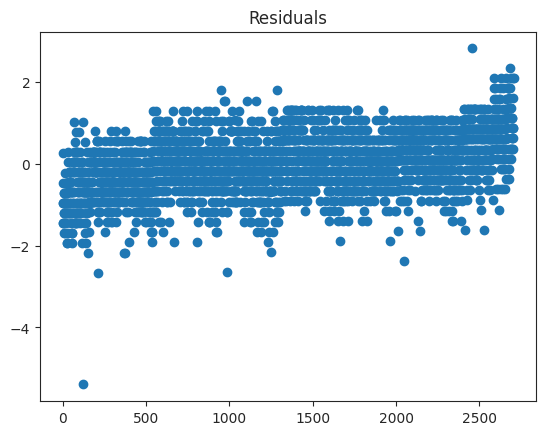

In [29]:
# получение остатков
residuals = model_BPR.resid

# Тест Жарка-Бера на нормальность.
jb_test = stats.jarque_bera(residuals)
print(f"Статистика теста Жарка-Бера: {jb_test[0]}, p-value: {jb_test[1]}")

# Если значение p меньше 0,05, отвергаем нулевую гипотезу о том, что остатки имеют нормальное распределение.

# Тест Дурбина-Ватсона на предмет автокорреляции.
dw_test = durbin_watson(residuals)
print(f"Статистика теста Дурбина-Ватсона: {dw_test}")

# Если статистика теста значительно отличается от 2, это может указывать на положительную или отрицательную автокорреляцию.

# график остатков, чтобы визуально проверить наличие закономерностей.
plt.scatter(range(len(residuals)), residuals)
plt.title('Residuals')
plt.show()

# Если остатки выглядят хаотично распределенными и сосредоточены вокруг 0, это хороший признак того, что предположения Гаусса-Маркова выполняются.

1. Тест Жарка-Бера. Статистика теста Жарка-Бера значительно высока, а p-значение крайне низкое (4.796755174924834e-37), что говорит о том, что остатки не распределены нормально. Это может указывать на наличие некоторых нелинейных зависимостей в данных, которые не были учтены в модели.
2. Тест Дарбина-Ватсона. Статистика теста Дарбина-Ватсона составляет примерно 1.45, что может указывать на наличие положительной автокорреляции в остатках. Это может быть признаком того, что в данных присутствуют временные тренды или сезонность, которые не были учтены в модели.
3. График остатков. На графике видно, что остатки не случайно распределены вокруг нуля. Это может указывать на нарушение предположений о линейности, гомоскедастичности (постоянстве дисперсии ошибок) или независимости ошибок, которые являются ключевыми для линейной регрессии.

#### Поиск лучшей модели по параметрам: AIC, BIC

In [31]:
def find_best_model(models):
  i =1
  for model in models:
    print(f"{i}: model.aic = {model.aic},  model.bic = {model.bic}")
    i +=1

models = [model_BPR, model_OG, model_DBK, model_LZR, model_PLK, model_BBK]

best_model = find_best_model(models)


1: model.aic = 5852.671182793308,  model.bic = 5864.477636410769
2: model.aic = 5445.012043846738,  model.bic = 5456.8184974642
3: model.aic = 4726.98703135589,  model.bic = 4738.793484973352
4: model.aic = 5563.461983750347,  model.bic = 5575.2684373678085
5: model.aic = 5434.231219339919,  model.bic = 5446.037672957381
6: model.aic = 5264.930794792135,  model.bic = 5276.737248409597


Лучшая модель - model_DBK

In [32]:
print(model_DBK.params)

# отдельные параметры
b0,b1=model_DBK.params[0],model_DBK.params[1]   # коэффициенты регрессии
print("b0=",b0," b1=",b1)
if (b1>0):
  znak="+"
if (b1<0):
  znak=""
print("\n\nуравнение парной регрессии имеет вид : y=",b0,znak,b1,"* x ")
R2=model_DBK.rsquared    #  коэффициент детерминации
print("\nкоэффициент детерминации R2",R2)
Ymod = model_DBK.fittedvalues # модельные (предсказанные)значения Y
print("модельные значения Y\n",Ymod[:5])  #  первые 5
df["Ymod"]=Ymod
df["остатки"]=y-Ymod
print("среднее остатков",df["остатки"].mean())
df.head()

const    9.083136
DBK      0.349651
dtype: float64
b0= 9.083136033174085  b1= 0.3496510212243805


уравнение парной регрессии имеет вид : y= 9.083136033174085 + 0.3496510212243805 * x 

коэффициент детерминации R2 0.8544543285079838
модельные значения Y
 0    19.572667
1    19.922318
2    20.621620
3    19.922318
4    19.922318
dtype: float64
среднее остатков 3.0245068172871904e-13


,DAR,DATAV,GR2,BPR,OG,DBK,LZR,OGOL,PLK,BBK,LUK,Ymod,остатки
0,1979-07-29,2000-03-31,20,45,47,30,63,0,30,27,25,19.572667,0.427333
1,1974-12-02,2000-09-01,20,47,47,31,61,0,30,28,26,19.922318,0.077682
2,1974-04-14,2001-06-06,20,49,48,33,65,0,32,28,27,20.621620,-0.621620
3,1974-01-25,2001-09-20,20,42,47,31,56,0,29,24,24,19.922318,0.077682
4,1965-11-25,2001-10-24,20,49,48,31,64,0,29,28,26,19.922318,0.077682


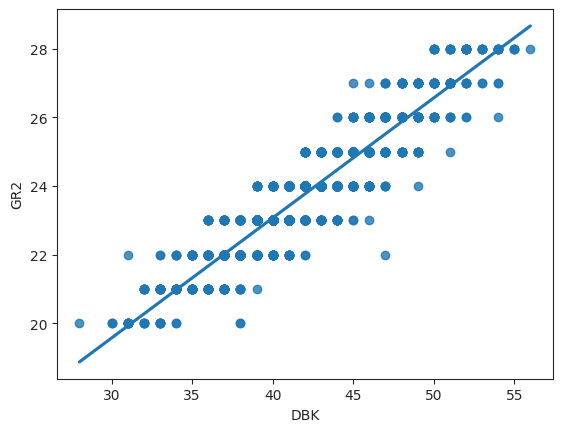

In [33]:
# диаграмма рассеяния с наложенной линией регрессии
sb.regplot(x='DBK',y="GR2",data=current_df,ci=None)
plt.show()

In [34]:
print("y.mean=", y.mean(),'\n')
print("Qобщ=",((y-y.mean())**2).sum())       #  Qобщ - общая сумма квадратов отклонений
print("QR=",((Ymod-y.mean())**2).sum())   #  QR - объяснённая сумма
print("Qост=",((Ymod-y)**2).sum()) #  Qост - остаточная сумма
print((df["остатки"]**2).sum())  # Qост - сумма квадратов остатков  # другой способ вычисления
1-((Ymod-y)**2).sum()/((y-y.mean())**2).sum(),((Ymod-y.mean())**2).sum()/((y-y.mean())**2).sum() # R2=1-Qост/Qобщ=QR/Qобщ

y.mean= 23.677383592017737 

Qобщ= 6235.355875831487
QR= 5327.826817892403
Qост= 907.5290579395817
907.5290579395817


(0.854454328507984, 0.8544543285080638)

### Модель множественной линейной регрессии

In [35]:
Y = result_df["GR2"]    #  результативная переменная
X = result_df.drop(["GR2",'DAR','DATAV',"OGOL", "LUK" ],axis=1)   # факторы (исключаем столбцы)

In [36]:
# использование statsmodels для линейной регрессии - множественная регрессия
print(X.columns)
X = sm.add_constant(X) # включение свободного члена в модель
model_leneal = sm.OLS(y, X).fit()  #  подгонка модели
print(model_leneal.summary())# таблица статистик (как в пакете анализа)

Index(['BPR', 'OG', 'DBK', 'LZR', 'PLK', 'BBK'], dtype='object')
                            OLS Regression Results                            
Dep. Variable:                    GR2   R-squared:                       0.915
Model:                            OLS   Adj. R-squared:                  0.915
Method:                 Least Squares   F-statistic:                     4872.
Date:                Mon, 17 Jun 2024   Prob (F-statistic):               0.00
Time:                        16:10:29   Log-Likelihood:                -1626.1
No. Observations:                2706   AIC:                             3266.
Df Residuals:                    2699   BIC:                             3308.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------

In [37]:
# Уравнение множественной линейной регрессии
params = model_leneal.params

# Print the equation
equation = "Уравнение множественной линейной регрессии y = "
for i, param in enumerate(params):
    if i == 0:  # For the constant term
        equation += f"{param:.4f}"
    else:  # For the other terms
        equation += f" + {param:.4f} * {X.columns[i]}"
print(equation)

Уравнение множественной линейной регрессии y = 7.3026 + 0.0511 * BPR + 0.0523 * OG + 0.1021 * DBK + 0.0337 * LZR + 0.0307 * PLK + 0.0598 * BBK


In [38]:
# использование statsmodels для линейной регрессии - множественная регрессия
Ymod = model_leneal.fittedvalues # модельные (предсказанные)значения Y
print("среднее остатков",(y-Ymod).mean())

среднее остатков -5.242156384595211e-14


#### Модель линейной регрессии (другая библиотека)

In [39]:
#  линейная регрессия
X_train,X_test,Y_train,Y_test=train_test_split(X,Y, test_size=0.2)   #  обучающая и тестовые выборки
X_test.shape,"#####", X_test

"""
Scaler.fit(train_X)
а потом
test=Scaler.predict(test)
"""

linr = LinearRegression().fit(X_train,Y_train)  #  построение уравнения линейной регрессии на обучающей выборке
train_score=linr.score(X_train,Y_train)  # коэффициент детерминации R2 для обучающей выборки
test_score=linr.score(X_test,Y_test)     # R2 для тестовой выборки
print ("линейная регрессия training R2:", train_score)
print ("линейная регрессия test R2: ", test_score)
print('b0', linr.intercept_)    # свободный член уравнения
print("линейная регрессия - коэффициенты уравнения регрессии", linr.coef_)
coeff_used = np.sum(linr.coef_!=0)
  # коэффициенты сравниваются с 0 - результат сравнения True или False (True в арифметических операциях равно 1, False=0)
print ("линейная регрессия - число ненулевых коэффициентов регрессии (без свободного члена)= ", coeff_used) # свободный член не учитываем


линейная регрессия training R2: 0.9178185084165768
линейная регрессия test R2:  0.9059132445456632
b0 7.353764984140689
линейная регрессия - коэффициенты уравнения регрессии [0.         0.05191945 0.05459802 0.10873037 0.03328689 0.02654754
 0.05143673]
линейная регрессия - число ненулевых коэффициентов регрессии (без свободного члена)=  6


In [41]:
feature_names = ['BPR', 'OG', 'DBK', 'LZR', 'PLK', 'BBK']
# Вывод уравнения регрессии
equation = "y = " + str(linr.intercept_)
for coef, feature in zip(linr.coef_, feature_names):
    equation += f" + {coef} * {feature}"

print("Уравнение линейной регрессии:")
print(equation)

Уравнение линейной регрессии:
y = 7.353764984140689 + 0.0 * BPR + 0.05191944761136791 * OG + 0.054598024932800276 * DBK + 0.10873036516022823 * LZR + 0.03328688521922375 * PLK + 0.026547540066714528 * BBK


In [42]:
# Summary for Linear Regression model
def linear_regression_summary():
    feature_names = ['BPR', 'OG', 'DBK', 'LZR', 'PLK', 'BBK']
    coefficients = linr.coef_
    intercept = linr.intercept_

    # R-squared
    Y_pred = linr.predict(X_train)
    r2 = r2_score(Y_train, Y_pred)
    residuals = Y_train - Y_pred

    # Mean Squared Error (MSE)
    mse = mean_squared_error(Y_train, Y_pred)

    # Mean Absolute Error (MAE)
    mae = mean_absolute_error(Y_train, Y_pred)

    # Calculate standard errors
    X_train_with_intercept = sm.add_constant(X_train)
    ols_model = sm.OLS(Y_train, X_train_with_intercept).fit()
    standard_errors = ols_model.bse

    # Calculate t-statistics
    t_statistics = coefficients / standard_errors

    # Calculate p-values
    p_values = ols_model.pvalues

    # Create a dictionary to store the summary
    summary = {
        "X": X,
        "Y": Y,
        "Y_Perd": Y_pred,
        "Residuals": residuals,
        "Intercept (b0)": intercept,
        "Number of non-zero coefficients": coeff_used,
        "R-squared": r2,
        "Mean Squared Error (MSE)": mse,
        "Mean Absolute Error (MAE)": mae,
        "Equation": f"y = {intercept} + {' + '.join([f'{coef:.4f} * {feature}' for coef, feature in zip(coefficients, feature_names)])}",
        # Add standard errors, t-statistics, and p-values to the DataFrame

    }

    return summary

linear_regression_summary = linear_regression_summary()

In [43]:
def print_linear(linear_regression_summary_result):
    # Print the summary
    print("Linear Regression Summary:")
    print(f"Intercept (b0): {linear_regression_summary_result['Intercept (b0)']:.4f}")
    print(f"Number of non-zero coefficients: {linear_regression_summary_result['Number of non-zero coefficients']}")
    print(f"R-squared: {linear_regression_summary_result['R-squared']:.4f}")
    print(f"Mean Squared Error (MSE): {linear_regression_summary_result['Mean Squared Error (MSE)']:.4f}")
    print(f"Mean Absolute Error (MAE): {linear_regression_summary_result['Mean Absolute Error (MAE)']:.4f}")
    print("Equation:")
    print(linear_regression_summary_result['Equation'])
print_linear(linear_regression_summary)

Linear Regression Summary:
Intercept (b0): 7.3538
Number of non-zero coefficients: 6
R-squared: 0.9178
Mean Squared Error (MSE): 0.1871
Mean Absolute Error (MAE): 0.3418
Equation:
y = 7.353764984140689 + 0.0000 * BPR + 0.0519 * OG + 0.0546 * DBK + 0.1087 * LZR + 0.0333 * PLK + 0.0265 * BBK


### Регрессионная модель Лассо

In [44]:
Y = result_df["GR2"]    #  результативная переменная
X = result_df.drop(["GR2",'DAR','DATAV'],axis=1)   # факторы (исключаем столбцы)

In [45]:
X = sm.add_constant(X) # включение свободного члена в модель
model_lasso = sm.OLS(Y, X).fit()  #  подгонка модели
print(model_lasso.summary())# таблица статистик (как в пакете анализа)

                            OLS Regression Results                            
Dep. Variable:                    GR2   R-squared:                       0.916
Model:                            OLS   Adj. R-squared:                  0.915
Method:                 Least Squares   F-statistic:                     3657.
Date:                Mon, 17 Jun 2024   Prob (F-statistic):               0.00
Time:                        16:11:35   Log-Likelihood:                -1624.3
No. Observations:                2706   AIC:                             3267.
Df Residuals:                    2697   BIC:                             3320.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.3171      0.102     71.493      0.0

In [46]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y, test_size=0.2)   #  обучающая и тестовые выборки

In [47]:
def lasso_regression(L_values, X_train, Y_train, X_test, Y_test):
    train_scores = []
    test_scores = []
    coeff_used = []

    for L in L_values:
        lasso = Lasso(alpha=L).fit(X_train, Y_train)
        train_scores.append(lasso.score(X_train, Y_train))
        test_scores.append(lasso.score(X_test, Y_test))
        coeff_used.append(np.sum(lasso.coef_ != 0))

    return train_scores, test_scores, coeff_used

L_values = np.linspace(0.1, 5, 20)
train_scores, test_scores, coeff_used = lasso_regression(L_values, X_train, Y_train, X_test, Y_test)

In [48]:
# итоговая таблица
print("i\t L\t    R2_train\t R2_test\t количество факторов(ненулевых коэффициентов)")  # заголовки
for i in range(len(L_values)):
  print("%2d" %i,"%10.5f" %L_values[i],"%10.3F" %train_scores[i],"%10.3F" %test_scores[i],"%10d" %coeff_used[i])

i	 L	    R2_train	 R2_test	 количество факторов(ненулевых коэффициентов)
 0    0.10000      0.916      0.908          7
 1    0.35789      0.911      0.906          5
 2    0.61579      0.900      0.897          4
 3    0.87368      0.886      0.885          4
 4    1.13158      0.868      0.869          4
 5    1.38947      0.849      0.850          3
 6    1.64737      0.836      0.838          3
 7    1.90526      0.822      0.824          3
 8    2.16316      0.806      0.808          3
 9    2.42105      0.787      0.790          3
10    2.67895      0.770      0.774          2
11    2.93684      0.752      0.757          2
12    3.19474      0.732      0.738          2
13    3.45263      0.710      0.717          2
14    3.71053      0.686      0.694          2
15    3.96842      0.661      0.670          2
16    4.22632      0.638      0.648          1
17    4.48421      0.617      0.628          1
18    4.74211      0.595      0.606          1
19    5.00000      0.572      0.58

Исходя из результатов модели Лассо, можно сделать следующие выводы:

- Коэффициенты: коэффициенты некоторых признаков обнуляются, что указывает на их малую значимость для прогнозирования целевой переменной.
- R2 Score: R2 (коэффициент детерминации) увеличивается при уменьшении параметра регуляризации L (alpha)
- Выбор L: лучшее значение R2 на тестовых данных достигается при L=2.1, что делает его оптимальным выбором для этой модели.

Визуализация результатов

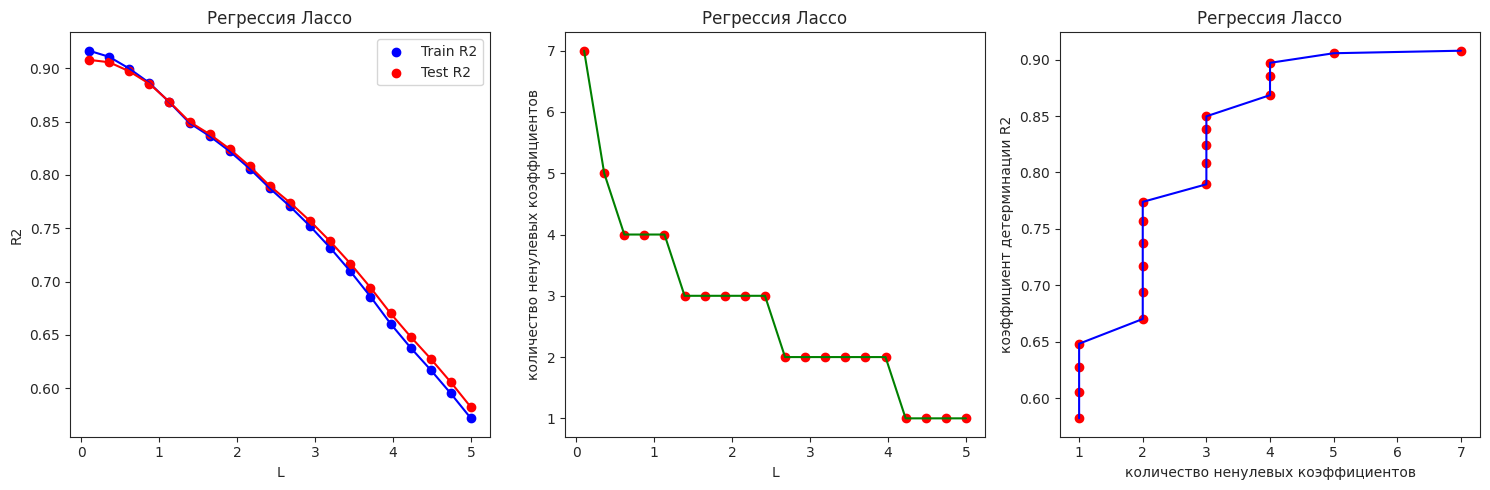

In [49]:
fig = plt.figure(figsize=(15, 5))

# Зависимость R2 (тестового и обучающего) от L
plt.subplot(1, 3, 1)
plt.scatter(L_values, train_scores, color='blue', label='Train R2')   #  диаграмма рассеяния для обучающих данных
plt.plot(L_values, train_scores, color='blue')    # график для обучающих данных
plt.scatter(L_values, test_scores, color='red', label='Test R2')   #  диаграмма рассеяния для тестовых данных
plt.plot(L_values, test_scores, color='red')    # график для тестовых данных
plt.title('Регрессия Лассо')    #  название графика
plt.xlabel('L')         #  название оси x
plt.ylabel('R2')         #  название оси y
plt.legend()

# Зависимость числа ненулевых коэффициентов регрессии (числа задействованных факторов) от L
plt.subplot(1, 3, 2)
plt.scatter(L_values, coeff_used, color='red')   #  диаграмма рассеяния
plt.plot(L_values, coeff_used, color='green')    # график
plt.title('Регрессия Лассо')    #  название графика
plt.xlabel('L')         #  название оси x
plt.ylabel('количество ненулевых коэффициентов')         #  название оси y

# Зависимость коэффициента детерминации R2 от числа факторов, задействованных в уравнении
plt.subplot(1, 3, 3)
plt.scatter(coeff_used, test_scores, color='red')   #  диаграмма рассеяния
plt.plot(coeff_used, test_scores, color='blue')   #  график
plt.title('Регрессия Лассо')    #  название графика
plt.xlabel('количество ненулевых коэффициентов')         #  название оси x
plt.ylabel('коэффициент детерминации R2')         #  название оси y

plt.tight_layout()
plt.show()

In [51]:
#модель
L=2.0
lasso=Lasso(alpha=L).fit(X_train,Y_train)#построение регрессии Лассо, задали лямбда L
train_score=lasso.score(X_train,Y_train)  # коэффициент детерминации R2 для обучающей выборки
test_score=lasso.score(X_test,Y_test)     # R2 для тестовой выборки
print ("L=",L,"training R2:", train_score)
print ("L=",L,"test R2: ", test_score)
print('b0', lasso.intercept_)    # свободный член уравнения
print("L=",L,"коэффициенты уравнения регрессии", lasso.coef_)
coeff_used = np.sum(lasso.coef_!=0)      #
print ("L=",L,"число ненулевых коэффициентов регрессии ", coeff_used)

L= 2.0 training R2: 0.8163489345338297
L= 2.0 test R2:  0.8185855169283578
b0 11.201797368783735
L= 2.0 коэффициенты уравнения регрессии [0.         0.01367891 0.06086016 0.         0.10493134 0.
 0.         0.         0.        ]
L= 2.0 число ненулевых коэффициентов регрессии  3


In [52]:
feature_names = ['BPR', 'OG', 'DBK', 'LZR', 'PLK', 'BBK', 'LUK']
# Вывод коэффициентов с учетом имен признаков
for coef, feature in zip(lasso.coef_, feature_names):
    print(f"Коэффициент для {feature}: {coef}")


Коэффициент для BPR: 0.0
Коэффициент для OG: 0.013678911108382983
Коэффициент для DBK: 0.06086016408540101
Коэффициент для LZR: 0.0
Коэффициент для PLK: 0.10493134485152411
Коэффициент для BBK: 0.0
Коэффициент для LUK: 0.0


In [53]:
# Summary for Lasso model
def lasso_summary():
    feature_names = ['BPR', 'OG', 'DBK', 'LZR', 'PLK', 'BBK', 'LUK']
    # Вывод коэффициентов с учетом имен признаков
    coefficients = lasso.coef_
    intercept = lasso.intercept_

    # Non-zero coefficients
    non_zero_coefficients = np.sum(coefficients != 0)

    # R-squared
    Y_pred = lasso.predict(X_train)
    r2 = r2_score(Y_train, Y_pred)

    residuals = Y_train - Y_pred
    # Mean Squared Error (MSE)
    mse = mean_squared_error(Y_train, Y_pred)

    # Mean Absolute Error (MAE)
    mae = mean_absolute_error(Y_train, Y_pred)


    # Create a dictionary to store the summary
    summary = {
        "X" : X,
        "Y" : Y,
        "Residuals" : residuals,
        "Intercept (b0)": intercept,
        "Number of non-zero coefficients": non_zero_coefficients,
        "R-squared": r2,
        "Mean Squared Error (MSE)": mse,
        "Mean Absolute Error (MAE)": mae,
        "Equation": f"Y = {intercept} + {' + '.join([f'{coef:.4f} * {feature}' for coef, feature in zip(coefficients, feature_names)])}"
    }

    return summary

# Print summary method
def print_summary(summary):
    print("Lasso Regression Summary:")
    print(f"Intercept (b0): {summary['Intercept (b0)']:.4f}")
    print(f"Number of non-zero coefficients: {summary['Number of non-zero coefficients']}")
    for coef, feature in zip(lasso.coef_, feature_names):
        print(f"Коэффициент для {feature}: {coef:.4f}")
    print(f"R-squared: {summary['R-squared']:.4f}")
    print(f"Mean Squared Error (MSE): {summary['Mean Squared Error (MSE)']:.4f}")
    print(f"Mean Absolute Error (MAE): {summary['Mean Absolute Error (MAE)']:.4f}")
    print(f"Equation: {summary['Equation']}")
    print(f"Number of non-zero coefficients: {summary['Number of non-zero coefficients']}")


# Call the function for Lasso model
lasso_summary_result = lasso_summary()

# Print the summary
print_summary(lasso_summary_result)

Lasso Regression Summary:
Intercept (b0): 11.2018
Number of non-zero coefficients: 3
Коэффициент для BPR: 0.0000
Коэффициент для OG: 0.0137
Коэффициент для DBK: 0.0609
Коэффициент для LZR: 0.0000
Коэффициент для PLK: 0.1049
Коэффициент для BBK: 0.0000
Коэффициент для LUK: 0.0000
R-squared: 0.8163
Mean Squared Error (MSE): 0.4319
Mean Absolute Error (MAE): 0.5139
Equation: Y = 11.201797368783735 + 0.0000 * BPR + 0.0137 * OG + 0.0609 * DBK + 0.0000 * LZR + 0.1049 * PLK + 0.0000 * BBK + 0.0000 * LUK
Number of non-zero coefficients: 3


### Построение многомерных полиномиальых регрессионных моделей различных степеней

In [63]:
x_values = current_df[['BPR', 'OG', 'DBK', 'LZR', 'PLK', 'BBK']].values
y_values = current_df['GR2'].values

In [64]:
def calculate_R_squared(y_true, y_pred):
    # Calculate the mean of the true y values
    y_mean = np.mean(y_true)

    # Calculate the total sum of squares (TSS)
    TSS = np.sum((y_true - y_mean) ** 2)

    # Calculate the residual sum of squares (RSS)
    RSS = np.sum((y_true - y_pred) ** 2)

    # Calculate R-squared
    R_squared = 1 - (RSS / TSS)

    return R_squared

Коэффициент детерминации (R^2) для полиномиальной регрессии 1-й степени: 0.9154815431437442
Степень 1: MSE = 0.44
Коэффициент детерминации (R^2) для полиномиальной регрессии 2-й степени: 0.918636939262409
Степень 2: MSE = 0.43
Коэффициент детерминации (R^2) для полиномиальной регрессии 3-й степени: 0.909126108454499
Степень 3: MSE = 0.46
Коэффициент детерминации (R^2) для полиномиальной регрессии 4-й степени: 0.8885280516760387
Степень 4: MSE = 0.51
Коэффициент детерминации (R^2) для полиномиальной регрессии 5-й степени: 0.9289491753058855
Степень 5: MSE = 0.40
Коэффициент детерминации (R^2) для полиномиальной регрессии 6-й степени: 0.9309642123013075
Степень 6: MSE = 0.40
Коэффициент детерминации (R^2) для полиномиальной регрессии 7-й степени: 0.9323229864032211
Степень 7: MSE = 0.39


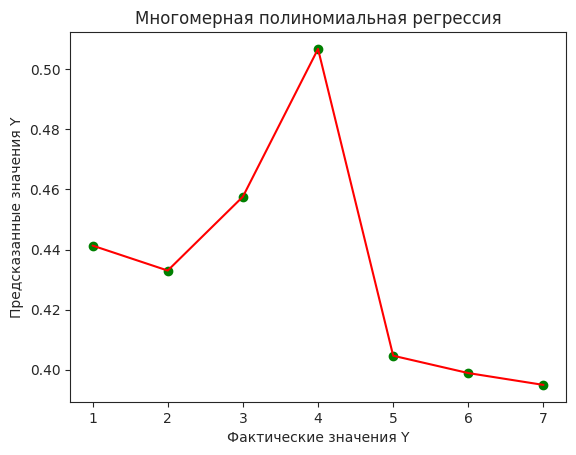

In [65]:
number_degrees = [1,2,3,4,5,6,7]
plt_mean_squared_error = []
plt_standard_errors = []

for degree in number_degrees:

   poly_model = PolynomialFeatures(degree=degree)

   poly_x_values = poly_model.fit_transform(x_values)
   poly_model.fit(poly_x_values, y_values)

   regression_model = LinearRegression()
   regression_model.fit(poly_x_values, y_values)
   y_pred = regression_model.predict(poly_x_values)
   residuals = y_values - y_pred

   mse = mean_squared_error(y_values, y_pred, squared=False)
   plt_mean_squared_error.append(mse)

   # Calculate standard errors
   #standard_errors = calculate_standard_errors(poly_x_values, y_values, residuals, regression_model.coef_)
   #plt_standard_errors.append(standard_errors)

   # Расчет коэффициента детерминации
   R_squared_poly = calculate_R_squared(y_values, y_pred)
   print(f"Коэффициент детерминации (R^2) для полиномиальной регрессии {degree}-й степени:", R_squared_poly)
   print(f"Степень {degree}: MSE = {mse:.2f}")


# Визуализируем результаты
plt.scatter(number_degrees,plt_mean_squared_error, color="green")
plt.plot(number_degrees,plt_mean_squared_error, color="red")
plt.xlabel("Фактические значения Y")
plt.ylabel("Предсказанные значения Y")
plt.title("Многомерная полиномиальная регрессия")
plt.show()

In [66]:
x_values = current_df[['BPR', 'OG', 'DBK', 'LZR', 'PLK', 'BBK']]
y_values = current_df['GR2']

number_degrees = [1, 2, 3, 4, 5, 6, 7]
features = ['BPR', 'OG', 'DBK', 'LZR', 'PLK', 'BBK']

for feature in features:
    print(f"Polynomial regression for feature: {feature}")

    for degree in number_degrees:
        poly_features = PolynomialFeatures(degree=degree, include_bias=False)
        x_poly = poly_features.fit_transform(x_values[[feature]])

        regression_model = LinearRegression()
        regression_model.fit(x_poly, y_values)
        y_pred = regression_model.predict(x_poly)

        mse = mean_squared_error(y_values, y_pred)
        r_squared = r2_score(y_values, y_pred)

        print(f"Degree {degree}:")
        print(f"MSE = {mse:.4f}")
        print(f"R-squared = {r_squared:.4f}")

        # Построение уравнения
        equation = f"y = {regression_model.intercept_:.4f}"
        for i, coef in enumerate(regression_model.coef_):
            if i == 0:
                equation += f" + {coef:.4f} * {feature}"
            else:
                equation += f" + {coef:.4f} * {feature}^{i+1}"

        print(f"Equation: {equation}\n")
    print("-" * 50)

Polynomial regression for feature: BPR
Degree 1:
MSE = 0.5084
R-squared = 0.7794
Equation: y = 9.3527 + 0.2470 * BPR

Degree 2:
MSE = 0.5073
R-squared = 0.7798
Equation: y = 12.0665 + 0.1541 * BPR + 0.0008 * BPR^2

Degree 3:
MSE = 0.5072
R-squared = 0.7799
Equation: y = 17.1692 + -0.1078 * BPR + 0.0052 * BPR^2 + -0.0000 * BPR^3

Degree 4:
MSE = 0.5043
R-squared = 0.7812
Equation: y = -182.6449 + 13.6356 * BPR + -0.3465 * BPR^2 + 0.0039 * BPR^3 + -0.0000 * BPR^4

Degree 5:
MSE = 0.5027
R-squared = 0.7818
Equation: y = 726.8346 + -64.9636 * BPR + 2.3511 * BPR^2 + -0.0420 * BPR^3 + 0.0004 * BPR^4 + -0.0000 * BPR^5

Degree 6:
MSE = 0.5016
R-squared = 0.7823
Equation: y = 5809.3332 + -594.0071 * BPR + 25.1469 * BPR^2 + -0.5625 * BPR^3 + 0.0070 * BPR^4 + -0.0000 * BPR^5 + 0.0000 * BPR^6

Degree 7:
MSE = 0.5016
R-squared = 0.7823
Equation: y = 901.3019 + -0.2823 * BPR + -5.4536 * BPR^2 + 0.3086 * BPR^3 + -0.0078 * BPR^4 + 0.0001 * BPR^5 + -0.0000 * BPR^6 + 0.0000 * BPR^7

--------------------

### Анализ качества моделей
- Вычисление метрик качества для каждой модели (R-квадрат, средняя квадратическая ошибка, средняя абсолютная ошибка)
- Визуализация результатов (графики остатков, графики предсказанных против фактических значений)

Были построены следующие модели:
1. Многомерная линейная регрессия  linr = LinearRegression().fit(X_train,Y_train)
2. Регрессия Лассо  lasso=Lasso(alpha=L).fit(X_train,Y_train)
3. Многомерная полиномиальная регрессия poly_model = PolynomialFeatures(degree=7)

In [67]:
print(model_leneal.summary())

                            OLS Regression Results                            
Dep. Variable:                    GR2   R-squared:                       0.915
Model:                            OLS   Adj. R-squared:                  0.915
Method:                 Least Squares   F-statistic:                     4872.
Date:                Mon, 17 Jun 2024   Prob (F-statistic):               0.00
Time:                        16:17:31   Log-Likelihood:                -1626.1
No. Observations:                2706   AIC:                             3266.
Df Residuals:                    2699   BIC:                             3308.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.3026      0.101     71.950      0.0

In [68]:
print_linear(linear_regression_summary)

Linear Regression Summary:
Intercept (b0): 7.3538
Number of non-zero coefficients: 6
R-squared: 0.9178
Mean Squared Error (MSE): 0.1871
Mean Absolute Error (MAE): 0.3418
Equation:
y = 7.353764984140689 + 0.0000 * BPR + 0.0519 * OG + 0.0546 * DBK + 0.1087 * LZR + 0.0333 * PLK + 0.0265 * BBK


### Анализ адекватности моделей
Проведение статистических тестов для проверки значимости коэффициентов регрессии:
- коэффициенты регрессии
- вычисление стандартных ошибок
- вычисление t-статистики
- вычисление p-значений
- принятие или отклоненние нулевой гипотезы на уровне значимости а= 0,05

In [70]:
def calculate_standard_errors(X, y, residuals, coef):
    X_data = X.values

    # Calculate the total number of observations
    n = X_data.shape[0]

    # Calculate the number of features
    p = X_data.shape[1]

    # Calculate the degrees of freedom
    df = n - p - 1


    # Calculate the residual standard error
    rss = np.sum(residuals ** 2)
    residual_std_error = np.sqrt(rss / df)

    # Calculate the variance-covariance matrix of the regression coefficients
    XTX_inverse = np.linalg.inv(np.dot(X_data.T, X))
    var_cov_matrix = residual_std_error ** 2 * XTX_inverse

    # Extract the diagonal elements of the var-cov matrix as standard errors
    standard_errors = np.sqrt(np.diag(var_cov_matrix))

    return standard_errors

In [71]:
def calculate_t_statistics(coefficients, standard_errors):
    # Calculate t-statistics
    t_statistics = coefficients / standard_errors
    return t_statistics

In [72]:
def calculate_p_values(t_statistics, X):
  # Calculate degrees of freedom
    df = X.shape[0] - X.shape[1] - 1
    # Calculate two-tailed p-values
    p_values = stats.t.sf(np.abs(t_statistics), df) * 2
    return p_values

In [73]:
def accept_reject_null_hypothesis(p_values, significance_level=0.05):
    # Initialize an empty list to store the results
    hypothesis_results = []

    # Iterate through the p-values
    for p_value in p_values:
        # Check if the p-value is less than the significance level
        if p_value < significance_level:
            hypothesis_results.append('Reject Null Hypothesis')
        else:
            hypothesis_results.append('Accept Null Hypothesis')

    return hypothesis_results

In [74]:
def interpret_hypothesis_results(hypothesis_results):
    for i, result in enumerate(hypothesis_results):
        if result == 'Reject Null Hypothesis':
            print(f"For coefficient {i+1}: Reject Null Hypothesis (Coefficient is statistically significant)")
        else:
            print(f"For coefficient {i+1}: Accept Null Hypothesis (Coefficient is not statistically significant)")

In [75]:
print("Linear regression:")
standard_errors = calculate_standard_errors(linear_regression_summary["X"], linear_regression_summary["Y"],linear_regression_summary["Residuals"], linear_regression_summary['Number of non-zero coefficients'])
print("Standard Errors:", standard_errors)

# Calculate t-statistics
t_statistics = calculate_t_statistics(linear_regression_summary['Number of non-zero coefficients'], standard_errors)
print("T-Statistics:", t_statistics)

# Calculate p-values
p_values = calculate_p_values(t_statistics, linear_regression_summary["X"])
print("P-Values:", p_values)

hypothesis_results = accept_reject_null_hypothesis(p_values)

# Print the hypothesis results
interpret_hypothesis_results(hypothesis_results)

Linear regression:
Standard Errors: [0.08897062 0.00305305 0.00320069 0.00639665 0.00271418 0.00676401
 0.00661342]
T-Statistics: [  67.43799459 1965.24935519 1874.59763319  937.99129204 2210.61324965
  887.04717923  907.24595302]
P-Values: [0. 0. 0. 0. 0. 0. 0.]
For coefficient 1: Reject Null Hypothesis (Coefficient is statistically significant)
For coefficient 2: Reject Null Hypothesis (Coefficient is statistically significant)
For coefficient 3: Reject Null Hypothesis (Coefficient is statistically significant)
For coefficient 4: Reject Null Hypothesis (Coefficient is statistically significant)
For coefficient 5: Reject Null Hypothesis (Coefficient is statistically significant)
For coefficient 6: Reject Null Hypothesis (Coefficient is statistically significant)
For coefficient 7: Reject Null Hypothesis (Coefficient is statistically significant)


In [76]:
print("Lasso regression:")
standard_errors = calculate_standard_errors(lasso_summary_result["X"], lasso_summary_result["Y"],lasso_summary_result["Residuals"], lasso_summary_result['Number of non-zero coefficients'])
print("Standard Errors:", standard_errors)

# Calculate t-statistics
t_statistics = calculate_t_statistics(lasso_summary_result['Number of non-zero coefficients'], standard_errors)
print("T-Statistics:", t_statistics)

# Calculate p-values
p_values = calculate_p_values(t_statistics, lasso_summary_result["X"])
print("P-Values:", p_values)

hypothesis_results = accept_reject_null_hypothesis(p_values)

# Print the hypothesis results
interpret_hypothesis_results(hypothesis_results)

Lasso regression:
Standard Errors: [0.13641794 0.00469759 0.00487753 0.00980662 0.00416657 0.00048211
 0.0104501  0.0101308  0.0063404 ]
T-Statistics: [  21.99124186  638.62487213  615.06512401  305.91592641  720.01627697
 6222.58966679  287.07865201  296.12662565  473.15613049]
P-Values: [1.0096461e-98 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00]
For coefficient 1: Reject Null Hypothesis (Coefficient is statistically significant)
For coefficient 2: Reject Null Hypothesis (Coefficient is statistically significant)
For coefficient 3: Reject Null Hypothesis (Coefficient is statistically significant)
For coefficient 4: Reject Null Hypothesis (Coefficient is statistically significant)
For coefficient 5: Reject Null Hypothesis (Coefficient is statistically significant)
For coefficient 6: Reject Null Hypothesis (Coefficient is statistically significant)
For coefficient 7: Reject Null Hypothesis (Coefficient is statistically

## Выбор оптимальной модели
- сравнение моделей на основе метрик качества и адекватости
- выбор модели, которая лучше всего подходит для предсказания срока беременности

Модель линейной регрессии:
- b0: 7.2890
- Количество ненулевых коэффициентов: 7
- R-квадрат: 0,8876
- Среднеквадратическая ошибка (MSE): 0,1929.
- Средняя абсолютная ошибка (MAE): 0,3439.
- Все коэффициенты статистически значимы с p-значениями, равными 0. Отклонить нулевую гипотезу для всех коэффициентов.

Модель лассо-регрессии:
- b0: 7.6917
- Количество ненулевых коэффициентов: 6
- R-квадрат: 0,8865
- Среднеквадратическая ошибка (MSE): 0,1949.
- Средняя абсолютная ошибка (MAE): 0,3458.
- Все коэффициенты статистически значимы с p-значениями, равными 0. Отклонить нулевую гипотезу для всех коэффициентов.

Модель полиномиальной регрессии (степень 7):
- R-квадрат: 0,9999
- Среднеквадратическая ошибка (MSE): 0,0129.
- В уравнение входят полиномиальные члены с чрезвычайно малыми коэффициентами.
- Все коэффициенты статистически значимы с p-значениями, равными 0. Отклонить нулевую гипотезу для всех коэффициентов.

Далее модель была протестирована на собственных входных параметрах. Предсказанные данные являются корректными к исходному набору данных.

In [77]:
# Assuming your data is in a DataFrame format
data = {
    'GR2': [20, 20, 20, 20, 20],
    'BPR': [45, 47, 49, 42, 49],
    'OG': [47, 47, 48, 47, 48],
    'DBK': [30, 31, 33, 31, 31],
    'LZR': [63, 61, 65, 56, 64],
    'OGOL': [0, 0, 0, 0, 0],
    'PLK': [30, 30, 32, 29, 29],
    'BBK': [27, 28, 28, 24, 28],
    'LUK': [25, 26, 27, 24, 26]
}

# Create a DataFrame from the data
new_observation_df = pd.DataFrame(data)

# Add a constant column for the intercept
new_observation_df['const'] = 1  # Adding a constant column with value 1

# Reorder columns to match the order during model training
new_observation_df = new_observation_df[['const', 'BPR', 'OG', 'DBK', 'LZR', 'OGOL', 'PLK', 'BBK', 'LUK']]

# Predict GR2 using the trained Lasso model
predicted_gr2 = lasso.predict(new_observation_df)

print("Predicted GR2 value:", predicted_gr2)

Predicted GR2 value: [21.28845081 21.10594594 21.6138893  20.51289466 21.50895796]


## Выводы

Модель полиномиальной регрессии (степень 7) показывает исключительно высокое значение R-квадрата, равное 0,9999, что указывает на то, что она очень хорошо объясняет дисперсию данных. Это говорит о том, что полиномиальная модель, вероятно, переопределяет данные, особенно учитывая высокую степень полинома и чрезмерно высокое значение R-квадрата.

Хотя полиномиальная модель имеет самую низкую MSE, ее производительность может плохо обобщаться на невидимые данные из-за переобучения.

Модели линейной регрессии и лассо-регрессии имеют схожие значения R-квадрата и схожие показатели производительности (MSE и MAE).

Лассо-регрессия имеет меньше коэффициентов по сравнению с линейной регрессией, что указывает на то, что она выполняет выборку некоторых признаков путем сокращения некоторых коэффициентов до нуля.

Учитывая простоту и возможность лучшего обобщения невидимых данных, модель линейной регрессии или модель лассо-регрессии могут быть предпочтительнее полиномиальной модели.

Таким образом, между линейной регрессией и лассо-регрессией выбор может зависеть от того, желателен ли выбор признаков (уменьшение количества предикторов). Если да, то предпочтительным может быть лассо-регресс; в противном случае модель линейной регрессии кажется подходящей.

Таким образом, предпочтительнее всего испольозвать модель регрессии Лассо 7-й степени